# Custom State
Node(Agent)간에 공유되는 상태정보를 커스터마이징할수 있다.

**최신 장소정보 공유**
- tool 장소검색api: naver/kakao/google map api(키워드 검색기반)
- tool 자연어 -> 검색을 위한 키워드추출
    - 나 여기 독산동인데, 여기 괜찮은 까페 추천해줘 -> 독산동 까페

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
KAKAO_API_KEY = os.getenv('KAKAO_API_KEY')

os.environ['LANGSMITH_TRACING'] = 'true'
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

## 카카오 장소검색 도구

https://developers.kakao.com/docs/latest/ko/local/dev-guide#search-by-keyword

In [ ]:
from langchain.tools import tool # Tool 데코레이터
import requests                  # http(rest-api) 요청 처리
from pprint import pprint
from typing import List, TypedDict # 타입 힌트

class KaKaoPlace(TypedDict):
    name: str
    address: str
    url: str

# 키워드를 이용해 카카오 장소 검색을 수행하는 툴
@tool
def kakao_place_search(query: str) -> List[KaKaoPlace]:
    """ 
    카카오 장소 검색 API를 호출하기 위한 도구

    Args:
        query: 검색어(키워드 기반)
    Returns:
        검색 결과
    """
    url = 'https://dapi.kakao.com/v2/local/search/keyword.json'
    headers = {
        'Authorization' : f'KakaoAK {KAKAO_API_KEY}'
    }
    params = {'query' : query, 'size' : 5} # 최대 5개 검색
    response = requests.get(url,headers=headers,params=params) # API 호출
    data = response.json()      # JSON -> Python dict
    data = data['documents']    # 장소 목록

    return [
    {
        'name' : place['place_name'] ,
        'address' : place['address_name'],
        'url' : place['place_url'],
    } for place in data
]

pprint(kakao_place_search.invoke({'query' : '독산동 맛집'}))


[{'address': '서울 금천구 독산동 163-2',
  'name': '왕래성',
  'url': 'http://place.map.kakao.com/538642507'},
 {'address': '서울 금천구 독산동 179-8',
  'name': '청정회센터',
  'url': 'http://place.map.kakao.com/9965001'},
 {'address': '서울 금천구 독산동 288-9',
  'name': '불맛전문관사부간짬뽕 독산직영점',
  'url': 'http://place.map.kakao.com/962610671'},
 {'address': '서울 금천구 독산동 1113',
  'name': '소하떡집',
  'url': 'http://place.map.kakao.com/1448413740'},
 {'address': '서울 금천구 독산동 378-428',
  'name': '돈유창',
  'url': 'http://place.map.kakao.com/1002142708'}]


# 키워드 추출 도구

In [6]:
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate

llm = init_chat_model('gpt-5.4-mini')

@tool
def extract_keyword(user_request: str) -> str:
    """
    사용자 요청에서 장소검색API를 사용하기 위한 짧고 명확한 키워드를 추출하는 도구
    장소검색도구(kakao_place_search)를 사용하기 전에 사용자의 요청을 먼저 변환하세요.
    """
    prompt = PromptTemplate.from_template('''
당신은 사용자의 요청을 장소검색에 필요한 키워드로 변환하는 전문가입니다.
장문의 사용자 요청에서 키워드를 한 문장으로 추출해주세요.
- 키워드는 띄워쓰기로 구분된 한 문장이어야 합니다.
- 다른 설명은 하지말고, 키워드만 추출합니다.

[사용자요청]
{user_request}


[예시]
- 여기 독산동인데, 소문난 맛집좀 알려줘봐 -> 독산동 맛집
- 부산 핫플 좀 알려줘봐 -> 부산 맛집

[금지어]
- 소문난
- 핫플
''')

    chain = prompt | llm
    response = chain.invoke({'user_request' : user_request})
    return response.content.strip().strip('"').strip("'")

print(extract_keyword.invoke('여기 독산역 근처인데, 소문난 맛집좀 알려줘'))
print(extract_keyword.invoke('서울에서 한잔 할거야 소문난 맛집좀 알려줘'))    
print(extract_keyword.invoke('대구에서 한잔 할거야 소문난 맛집좀 알려줘'))    
print(extract_keyword.invoke('부산에서 한잔 할거야 소문난 맛집좀 알려줘'))    
print(extract_keyword.invoke('광주에서 한잔 할거야 소문난 맛집좀 알려줘'))
print(extract_keyword.invoke('대전에서 한잔 할거야 소문난 맛집좀 알려줘'))


독산역 맛집
서울 맛집
대구 맛집
부산 맛집
광주 맛집
대전 맛집


## 그래프 구성
- 키워드 추출 -> 카카오 장소 검색 -> 상태(State)에 결과를 저장하는 LangGraph

In [8]:
from langgraph.graph import StateGraph, START, END # 그래프 구성 요소
from langgraph.prebuilt import ToolNode, tools_condition # 도구 노드, 분기 조건
from typing import Annotated, Optional       # 타입 힌트 도구
from langgraph.graph.message import add_messages # 메시지 누적 처리를 해줄 헬퍼
from langchain_core.messages import BaseMessage, ToolMessage # 메시지 타입

# 그래프에서 사용할 상태(TypedDict) 스키마
class State(TypedDict):
    # messages 필드 리스트를 add_messages 규칙으로 누적 저장
    messages: Annotated[List[BaseMessage], add_messages]
    search_query : Optional[str] # 검색 키워드
    search_results : Optional[List[KaKaoPlace]] # 장소 검색 결과
     
llm = init_chat_model('gpt-5.4-mini')
tools = [kakao_place_search, extract_keyword]
llm_with_tools = llm.bind_tools(tools) # llm에 도구 스펙 바인딩

# State의 messages 를 입력으로 받아, 응답 메시지를 추가해주는 노드 함수
def chatbot(state: State):
    # 직전에 도구 실행을 한 경우
    if isinstance(state['messages'][-1], ToolMessage):
        # 키워드 추출 도구면
        if state['messages'][-1].name == 'extract_keyword':
            # 검색 키워드 저장
            state['search_query'] = state['messages'][-1].content
        # 장소 검색 추출 도구면
        elif state['messages'][-1].name == 'kakao_place_search':
            # 검색 결과 저장
            state['search_results'] = state['messages'][-1].content
                        
    # 누적된 메시지 리스트로 LLM 호출
    response = llm_with_tools.invoke(state['messages']) 
    # state 상태 유지 + 새 응답 메시지 누적 반환
    return {**state, 'messages': [response]} 

<class 'langgraph.graph.state.CompiledStateGraph'>


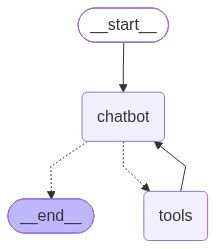

In [9]:
# langgraph.prebuilt 모듈의 ToolNode, tools_condition 함수 사용한 워크플로우
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

# State 스키마 기반 그래프 설계 객체 생성
builder = StateGraph(State) 
tool_node = ToolNode(tools)

# 시작 노드 -> chatbot 노드
builder.add_edge(START, 'chatbot') 

builder.add_node('chatbot', chatbot) # chatbot 노드
builder.add_node('tools', tool_node) # tools 노드

builder.add_conditional_edges('chatbot', tools_condition)
builder.add_edge('tools','chatbot')

graph = builder.compile() # 그래프 컴파일
print(type(graph)) # 그래프 타입 확인
graph # 그래프 객체

# 그래프 실행

In [ ]:
# 그래프 실행 초기상태
initial_state: State = {
    'messages' : [('human', '독산역 맛집 알려줘')],
    'search_query' :None,
    'search_results' :None
}

final_state = graph.invoke(initial_state) # 그래프 실행 : 키워드 추출 -> 장소 검색 -> 응답 생성
final_state

{'messages': [HumanMessage(content='독산역 맛집 알려줘', additional_kwargs={}, response_metadata={}, id='24458056-a393-4fa5-8d79-154faa8e3282'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 219, 'total_tokens': 243, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EJw5w18SezUjdbfje8giVD8VQFEpP', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a06627-6e1b-7d72-94d6-35a3094c8aee-0', tool_calls=[{'name': 'extract_keyword', 'args': {'user_request': '독산역 맛집 알려줘'}, 'id': 'call_D6N8IajIpfhnjxKEOu0vR6Fy', 'type':

In [ ]:
from IPython.display import Markdown # Jypyter - Markdown 렌더링

Markdown(final_state['messages'][-1].content) # 마지막 메시지 마크다운 형식 출력

독산역 근처 맛집으로 이런 곳들이 검색됐어요:

1. **도원**  
   - 서울 금천구 가산동 685  
   - [카카오맵 보기](http://place.map.kakao.com/1713311171)

2. **다온푸드**  
   - 서울 금천구 가산동 673  
   - [카카오맵 보기](http://place.map.kakao.com/1730488332)

3. **모리스시**  
   - 서울 금천구 가산동 673  
   - [카카오맵 보기](http://place.map.kakao.com/1777821112)

4. **칼포니치킨&호프 독산역점**  
   - 서울 금천구 독산동 1006-23  
   - [카카오맵 보기](http://place.map.kakao.com/16767884)

5. **태우마 본점**  
   - 서울 금천구 독산동 1142  
   - [카카오맵 보기](http://place.map.kakao.com/2037687026)

원하시면 제가 이어서  
- **한식/중식/일식/치킨**처럼 종류별로 골라드리거나  
- **평점 높은 곳 위주로** 다시 찾아드릴게요.

# 그래프 디버깅

In [ ]:
for msg in final_state['messages']:
    msg.pretty_print() # 보기 좋은 형식 출력

================================ Human Message =================================

독산역 맛집 알려줘
================================== Ai Message ==================================
Tool Calls:
  extract_keyword (call_D6N8IajIpfhnjxKEOu0vR6Fy)
 Call ID: call_D6N8IajIpfhnjxKEOu0vR6Fy
  Args:
    user_request: 독산역 맛집 알려줘
================================= Tool Message =================================
Name: extract_keyword

독산역 맛집
================================== Ai Message ==================================
Tool Calls:
  kakao_place_search (call_7p8a36Zv55IXDMhjrvNe0rGf)
 Call ID: call_7p8a36Zv55IXDMhjrvNe0rGf
  Args:
    query: 독산역 맛집
================================= Tool Message =================================
Name: kakao_place_search

[{"name": "도원", "address": "서울 금천구 가산동 685", "url": "http://place.map.kakao.com/1713311171"}, {"name": "다온푸드", "address": "서울 금천구 가산동 673", "url": "http://place.map.kakao.com/1730488332"}, {"name": "모리스시", "address": "서울 금천구 가산동 673", "url": "http://place.m

In [ ]:
# LangGraph 스트리밍 실행 : 노드별 실행 결과를 실시간 확인
# 그래프 실행 초기상태
initial_state: State = {
    'messages' : [('human', '독산역 돈까스 맛집 알려줘')],
    'search_query' :None,
    'search_results' :None
}

# 그래프를 스트리밍 방식으로 실행 (stream_mode='updates' : 기본값 => 실행 중간마다 결과 전달)
for chunk in graph.stream(initial_state, stream_mode='updates'):
    for node, update in chunk.items(): # (실행된 노드, 해당 업데이트)
        print(f"{node} node")
        update['messages'][-1].pretty_print() # 해당 노드에 추가된 마지막 메시지
    print()

chatbot node
================================== Ai Message ==================================
Tool Calls:
  extract_keyword (call_ZQdiutfMt3Y0zdlKaT51TcgG)
 Call ID: call_ZQdiutfMt3Y0zdlKaT51TcgG
  Args:
    user_request: 독산역 돈까스 맛집 알려줘

tools node
================================= Tool Message =================================
Name: extract_keyword

독산역 돈까스 맛집

chatbot node
================================== Ai Message ==================================
Tool Calls:
  kakao_place_search (call_vivFpfFRiybwUno9M34S9rwD)
 Call ID: call_vivFpfFRiybwUno9M34S9rwD
  Args:
    query: 독산역 돈까스 맛집

tools node
================================= Tool Message =================================
Name: kakao_place_search

[{"name": "히나타", "address": "서울 금천구 가산동 673", "url": "http://place.map.kakao.com/1788547704"}, {"name": "이박사생돈까스", "address": "서울 금천구 독산동 1047-4", "url": "http://place.map.kakao.com/357199342"}, {"name": "수작카츠 독산점", "address": "서울 금천구 독산동 291-1", "url": "http://place.map.kakao.com/19424